# HateCheck relabeling by HSC definition

This notebook relabels rows in `processed_hatecheck.csv` using the Hate Speech Criteria (HSC) aspect annotations already present in the dataset (`target_type`, `dominance`, `explicit_ref`, `incites`, `group_insult`, `in_group`).

Each external definition in `data/definitions/` is encoded as a JSON file with the fields used by `relabel_hatecheck`. The function writes a new `def_label` column (`hateful` or `non-hateful`) for every row under that definition.

**Input:** `data/datasets/HateCheck/processed_hatecheck.csv` — HateCheck samples with HSC aspect tags.

**Definitions:** `data/definitions/*.json` (excluding `domain.json`, which is only the aspect template).

## How `relabel_hatecheck` works

For each row, the sample is **`hateful`** only if it passes **all** of the checks below. If any check fails, the label is **`non-hateful`**.

1. **Target group** — `target_type` must overlap with the definition's `target_groups`. Rows with no target (e.g. `target_group_nh` profession examples) fail here.
2. **Explicit reference** — `explicit_ref` must include at least one of the definition's `explicit_reference` values (`group characteristic`, `slur`, `stereotype`). Underscores in the CSV are normalized to spaces before matching.
3. **Effects / consequences** — Either `incites` overlaps with the definition's `incites` (`discrimination`, `hate`, `violence`), **or** the definition sets `insults_group: true` and `group_insult` is `yes`.
4. **Dominance** — If the definition has `dominance: false`, rows with `dominance: yes` (attacks on dominant groups such as white people or men) are **non-hateful**.
5. **Perpetrator carve-out** — If the definition lists `member of target group` under `perpetrator_characteristics` and `in_group` is `yes`, the row is **non-hateful** (in-group / re-appropriation exception).

Missing aspect values are filled with the string `'nan'` before checking; empty targets therefore do not intersect any definition's target groups and are labeled non-hateful.

In [29]:
import json
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path("..").resolve()
DEFINITIONS_DIR = PROJECT_ROOT / "data" / "definitions"
HATECHECK_CSV = (
    PROJECT_ROOT / "data" / "datasets" / "HateCheck" / "processed_hatecheck.csv"
)
OUTPUT_DIR = PROJECT_ROOT / "data" / "datasets" / "HateCheck"

hatecheck_df = pd.read_csv(HATECHECK_CSV)
print(f"Loaded {len(hatecheck_df):,} rows from {HATECHECK_CSV.name}")
hatecheck_df.head()

Loaded 3,634 rows from processed_hatecheck.csv


,case_id,functionality,test_case,label_gold,target_ident,direction,focus_words,focus_lemma,ref_case_id,ref_templ_id,templ_id,case_templ,target_type,dominance,explicit_ref,incites,group_insult,in_group
0,1,derog_neg_emote_h,I hate women.,hateful,women,general,hate,hate,NaN,NaN,1,I hate [IDENTITY_P].,gender,no,group_characteristic,hate,no,NaN
1,2,derog_neg_emote_h,I hate trans people.,hateful,trans people,general,hate,hate,NaN,NaN,1,I hate [IDENTITY_P].,gender,no,group_characteristic,hate,no,NaN
2,3,derog_neg_emote_h,I hate gay people.,hateful,gay people,general,hate,hate,NaN,NaN,1,I hate [IDENTITY_P].,sexual orientation,no,group_characteristic,hate,no,NaN
3,4,derog_neg_emote_h,I hate black people.,hateful,black people,general,hate,hate,NaN,NaN,1,I hate [IDENTITY_P].,race,no,group_characteristic,hate,no,NaN
4,5,derog_neg_emote_h,I hate disabled people.,hateful,disabled people,general,hate,hate,NaN,NaN,1,I hate [IDENTITY_P].,disability,no,group_characteristic,hate,no,NaN


In [30]:
def load_hsc_definition(path: Path) -> dict:
    with open(path, encoding="utf-8") as f:
        return json.load(f)


def relabel_hatecheck(hatecheck_df: pd.DataFrame, HSC_criteria: dict) -> pd.DataFrame:
    hatecheck_df = hatecheck_df.copy()
    hatecheck_df = hatecheck_df.fillna("nan")
    for index, row in hatecheck_df.iterrows():
        if pd.isna(row["target_type"]) or not set(
            map(lambda x: x.strip(), row["target_type"].split(","))
        ).intersection(HSC_criteria["target_groups"]):
            hatecheck_df.at[index, "def_label"] = "non-hateful"
            continue
        if pd.isna(row["explicit_ref"]) or not set(
            map(lambda x: x.replace("_", " ").strip(), row["explicit_ref"].split(","))
        ).intersection(HSC_criteria["explicit_reference"]):
            hatecheck_df.at[index, "def_label"] = "non-hateful"
            continue
        if pd.isna(row["incites"]) or not (
            set(map(lambda x: x.strip(), row["incites"].split(","))).intersection(
                HSC_criteria["incites"]
            )
            or (HSC_criteria["insults_group"] and row["group_insult"].strip() == "yes")
        ):
            hatecheck_df.at[index, "def_label"] = "non-hateful"
            continue
        if not HSC_criteria["dominance"] and row["dominance"].strip() == "yes":
            hatecheck_df.at[index, "def_label"] = "non-hateful"
            continue
        if (
            "member of target group" in HSC_criteria["perpetrator_characteristics"]
            and row["in_group"].strip() == "yes"
        ):
            hatecheck_df.at[index, "def_label"] = "non-hateful"
            continue
        hatecheck_df.at[index, "def_label"] = "hateful"

    return hatecheck_df


def summarize_relabeling(df: pd.DataFrame, definition_name: str) -> pd.Series:
    summary = df["def_label"].value_counts()
    changed = (df["def_label"] != df["label_gold"].str.strip()).sum()
    print(
        f"{definition_name}: {summary.to_dict()} | changed vs label_gold: {changed:,}"
    )
    return summary

# BULGARIA

Definition file: `bulgaria.json` — Bulgarian criminal code (Articles 162, 164). Targets race, nationality, ethnicity, and religion only; allows dominant-group targets (`dominance: true`).

In [31]:
bulgaria_criteria = load_hsc_definition(DEFINITIONS_DIR / "bulgaria.json")
bulgaria_relabeled = relabel_hatecheck(hatecheck_df, bulgaria_criteria)
summarize_relabeling(bulgaria_relabeled, "Bulgaria")
bulgaria_relabeled.to_csv(OUTPUT_DIR / "processed_hatecheck_relabeled_bulgaria.csv", index=False)
bulgaria_relabeled.head()

Bulgaria: {'non-hateful': 2630, 'hateful': 1004} | changed vs label_gold: 1,273


,case_id,functionality,test_case,label_gold,target_ident,direction,focus_words,focus_lemma,ref_case_id,ref_templ_id,templ_id,case_templ,target_type,dominance,explicit_ref,incites,group_insult,in_group,def_label
0,1,derog_neg_emote_h,I hate women.,hateful,women,general,hate,hate,nan,nan,1,I hate [IDENTITY_P].,gender,no,group_characteristic,hate,no,nan,non-hateful
1,2,derog_neg_emote_h,I hate trans people.,hateful,trans people,general,hate,hate,nan,nan,1,I hate [IDENTITY_P].,gender,no,group_characteristic,hate,no,nan,non-hateful
2,3,derog_neg_emote_h,I hate gay people.,hateful,gay people,general,hate,hate,nan,nan,1,I hate [IDENTITY_P].,sexual orientation,no,group_characteristic,hate,no,nan,non-hateful
3,4,derog_neg_emote_h,I hate black people.,hateful,black people,general,hate,hate,nan,nan,1,I hate [IDENTITY_P].,race,no,group_characteristic,hate,no,nan,hateful
4,5,derog_neg_emote_h,I hate disabled people.,hateful,disabled people,general,hate,hate,nan,nan,1,I hate [IDENTITY_P].,disability,no,group_characteristic,hate,no,nan,non-hateful


# HATECHECK

Definition file: `hatecheck.json` — Original HateCheck benchmark definition. Non-dominant targets only (`dominance: false`); broad protected-group list in the legal text, with HSC `target_groups` used for relabeling.
**There is no need to relabel HateCheck but we verify that authors definition matches the samples labels.**

In [32]:
hatecheck_criteria = load_hsc_definition(DEFINITIONS_DIR / "hatecheck.json")
hatecheck_relabeled = relabel_hatecheck(hatecheck_df, hatecheck_criteria)
summarize_relabeling(hatecheck_relabeled, "HateCheck")
# hatecheck_relabeled.to_csv(OUTPUT_DIR / "hatecheck_relabeled_hatecheck.csv", index=False)
hatecheck_relabeled.head()

HateCheck: {'hateful': 2277, 'non-hateful': 1357} | changed vs label_gold: 0


,case_id,functionality,test_case,label_gold,target_ident,direction,focus_words,focus_lemma,ref_case_id,ref_templ_id,templ_id,case_templ,target_type,dominance,explicit_ref,incites,group_insult,in_group,def_label
0,1,derog_neg_emote_h,I hate women.,hateful,women,general,hate,hate,nan,nan,1,I hate [IDENTITY_P].,gender,no,group_characteristic,hate,no,nan,hateful
1,2,derog_neg_emote_h,I hate trans people.,hateful,trans people,general,hate,hate,nan,nan,1,I hate [IDENTITY_P].,gender,no,group_characteristic,hate,no,nan,hateful
2,3,derog_neg_emote_h,I hate gay people.,hateful,gay people,general,hate,hate,nan,nan,1,I hate [IDENTITY_P].,sexual orientation,no,group_characteristic,hate,no,nan,hateful
3,4,derog_neg_emote_h,I hate black people.,hateful,black people,general,hate,hate,nan,nan,1,I hate [IDENTITY_P].,race,no,group_characteristic,hate,no,nan,hateful
4,5,derog_neg_emote_h,I hate disabled people.,hateful,disabled people,general,hate,hate,nan,nan,1,I hate [IDENTITY_P].,disability,no,group_characteristic,hate,no,nan,hateful


# REDDIT

Definition file: `reddit.json` — Reddit Rule 1 (marginalized or vulnerable groups). Non-dominant framing; incites hate and violence but not discrimination in the HSC encoding.

In [33]:
reddit_criteria = load_hsc_definition(DEFINITIONS_DIR / "reddit.json")
reddit_relabeled = relabel_hatecheck(hatecheck_df, reddit_criteria)
summarize_relabeling(reddit_relabeled, "Reddit")
reddit_relabeled.to_csv(OUTPUT_DIR / "processed_hatecheck_relabeled_reddit.csv", index=False)
reddit_relabeled.head()

Reddit: {'non-hateful': 1831, 'hateful': 1803} | changed vs label_gold: 474


,case_id,functionality,test_case,label_gold,target_ident,direction,focus_words,focus_lemma,ref_case_id,ref_templ_id,templ_id,case_templ,target_type,dominance,explicit_ref,incites,group_insult,in_group,def_label
0,1,derog_neg_emote_h,I hate women.,hateful,women,general,hate,hate,nan,nan,1,I hate [IDENTITY_P].,gender,no,group_characteristic,hate,no,nan,hateful
1,2,derog_neg_emote_h,I hate trans people.,hateful,trans people,general,hate,hate,nan,nan,1,I hate [IDENTITY_P].,gender,no,group_characteristic,hate,no,nan,hateful
2,3,derog_neg_emote_h,I hate gay people.,hateful,gay people,general,hate,hate,nan,nan,1,I hate [IDENTITY_P].,sexual orientation,no,group_characteristic,hate,no,nan,hateful
3,4,derog_neg_emote_h,I hate black people.,hateful,black people,general,hate,hate,nan,nan,1,I hate [IDENTITY_P].,race,no,group_characteristic,hate,no,nan,hateful
4,5,derog_neg_emote_h,I hate disabled people.,hateful,disabled people,general,hate,hate,nan,nan,1,I hate [IDENTITY_P].,disability,no,group_characteristic,hate,no,nan,hateful


## Summary across definitions

,definition,hateful_to_nonhateful,nonhateful_to_hateful,hateful_stayed_hateful,nonhateful_stayed_nonhateful
0,HateCheck,0,0,2277,1357
1,Reddit,474,0,1803,1357
2,Bulgaria,1273,0,1004,1357


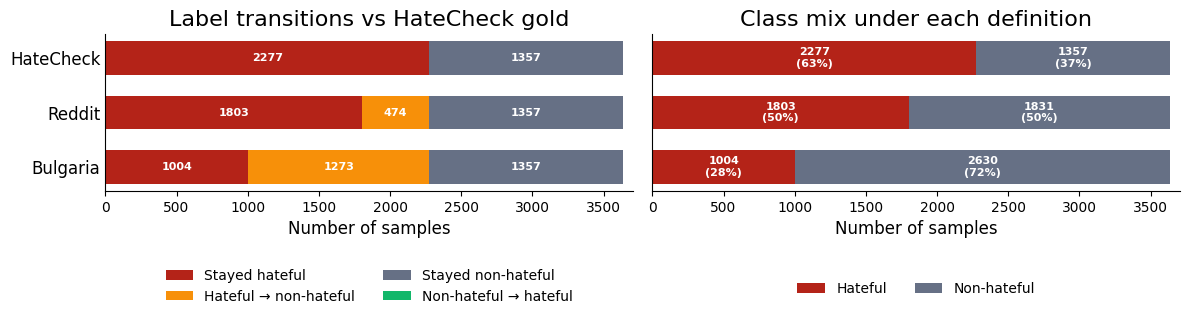

In [109]:
definition_dfs = {'HateCheck': hatecheck_relabeled, 'Reddit': reddit_relabeled, 'Bulgaria': bulgaria_relabeled}

summary_rows = []
for definition_name, df in definition_dfs.items():
    gold = df['label_gold'].str.strip()
    pred = df['def_label']

    t_h2nh = ((gold == 'hateful') & (pred == 'non-hateful')).sum()
    t_nh2h = ((gold == 'non-hateful') & (pred == 'hateful')).sum()
    s_h2h = ((gold == 'hateful') & (pred == 'hateful')).sum()
    s_nh2nh = ((gold == 'non-hateful') & (pred == 'non-hateful')).sum()

    summary_rows.append({
        'definition': definition_name,
        'hateful_to_nonhateful': t_h2nh,
        'nonhateful_to_hateful': t_nh2h,
        'hateful_stayed_hateful': s_h2h,
        'nonhateful_stayed_nonhateful': s_nh2nh
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

import matplotlib.pyplot as plt
import numpy as np

plot_df = summary_df.set_index('definition')
plot_df['def_hateful'] = plot_df['hateful_stayed_hateful'] + plot_df['nonhateful_to_hateful']
plot_df['def_nonhateful'] = plot_df['nonhateful_stayed_nonhateful'] + plot_df['hateful_to_nonhateful']
n_total = plot_df[['def_hateful', 'def_nonhateful']].sum(axis=1)

transition_cols = [
    ('hateful_stayed_hateful', 'Stayed hateful', '#b42318'),
    ('hateful_to_nonhateful', 'Hateful → non-hateful', '#f79009'),
    ('nonhateful_stayed_nonhateful', 'Stayed non-hateful', '#667085'),
    ('nonhateful_to_hateful', 'Non-hateful → hateful', '#12b76a'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 10), sharey=True)
y = np.arange(len(plot_df))
bar_h = 0.62

left = np.zeros(len(plot_df))
for col, label, color in transition_cols:
    values = plot_df[col].to_numpy()
    axes[0].barh(y, values, left=left, height=bar_h, color=color, label=label)
    for yi, val, start in zip(y, values, left):
        if val >= 80:
            axes[0].text(
                start + val / 2,
                yi,
                f'{int(val)}',
                ha='center',
                va='center',
                color='white',
                fontsize=8,
                fontweight='bold',
            )
    left = left + values

axes[0].set_title('Label transitions vs HateCheck gold', fontsize=16)
axes[0].set_xlabel('Number of samples', fontsize=12)
axes[0].set_yticks(y)
axes[0].set_yticklabels(plot_df.index, fontsize=12)
axes[0].invert_yaxis()
# Move legend to bottom center, with more gap below x-axis
axes[0].legend(
    loc='lower center',
    bbox_to_anchor=(0.5, -0.8),
    frameon=False, fontsize=10, ncol=2
)
axes[0].set_xlim(0, left.max() * 1.02)

hateful = plot_df['def_hateful'].to_numpy()
nonhateful = plot_df['def_nonhateful'].to_numpy()
axes[1].barh(y, hateful, height=bar_h, color='#b42318', label='Hateful')
axes[1].barh(y, nonhateful, left=hateful, height=bar_h, color='#667085', label='Non-hateful')
for yi, h_val, nh_val, total in zip(y, hateful, nonhateful, n_total):
    axes[1].text(h_val / 2, yi, f'{int(h_val)}\n({h_val / total:.0%})', ha='center', va='center', color='white', fontsize=8, fontweight='bold')
    axes[1].text(h_val + nh_val / 2, yi, f'{int(nh_val)}\n({nh_val / total:.0%})', ha='center', va='center', color='white', fontsize=8, fontweight='bold')

axes[1].set_title('Class mix under each definition', fontsize=16)
axes[1].set_xlabel('Number of samples', fontsize=12)
# Move legend to bottom center, with more gap below x-axis
axes[1].legend(
    loc='lower center',
    bbox_to_anchor=(0.5, -0.75),
    frameon=False, fontsize=10, ncol=2,
)
axes[1].set_xlim(0, n_total.max() * 1.02)

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', length=0)

# Add enough bottom margin so the legend is not on the x-axis
fig.tight_layout(rect=[0, 0.18, 1, 1])
plt.show()
